<a href="https://colab.research.google.com/github/jonitodev/pcvk26_8_joniyogakusuma/blob/main/Week6_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
NAMA = 'Joni Yoga Kusuma'
NIM = '254107023003'
NO_ABSEN = 8
SEED = int(NIM[-3:])

print('Nama  :', NAMA)
print('NIM   :', NIM)
print('Absen :', NO_ABSEN)

Nama  : Joni Yoga Kusuma
NIM   : 254107023003
Absen : 8


# Week 6 - Filter Spasial
**Joni Yoga Kusuma | 254107023003 | Absen 8**

Ubah `FOLDER` sesuai lokasi data Anda. Folder tersebut berisi `mandrill.tiff`, `lena.jpg`, dan `djawatan.jpg`. Jalankan semua sel dari atas.

In [8]:
from pathlib import Path
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Jika pustaka belum tersedia pada Jupyter lokal, jalankan sekali:
# %pip install numpy matplotlib opencv-python-headless torch

plt.rcParams.update({'figure.dpi':100,'font.size':10,'axes.titlesize':10})
print('OpenCV:',cv.__version__,'| NumPy:',np.__version__,'| PyTorch:',torch.__version__)

OpenCV: 5.0.0 | NumPy: 2.1.3 | PyTorch: 2.11.0+cpu


In [9]:
# Google Colab: hubungkan Drive dan sesuaikan lokasi folder gambar.
try:
    from google.colab import drive
except ImportError:
    FOLDER = Path('data_week6')  # Jupyter lokal: folder di samping notebook
else:
    drive.mount('/content/drive')
    FOLDER = Path('/content/drive/MyDrive/PCVK/Week6')  # Ganti sesuai folder Anda

print('Folder gambar:', FOLDER)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder gambar: /content/drive/MyDrive/PCVK/Week6


In [10]:
def baca(nama):
    data=np.fromfile(FOLDER/nama,dtype=np.uint8)
    img=cv.imdecode(data,cv.IMREAD_COLOR)
    if img is None:
        raise ValueError(f'Gagal membaca {nama}')
    return img

def uint8(img):
    return np.clip(np.rint(img),0,255).astype(np.uint8)

def tampil(images,titles,kolom=3,ukuran=4):
    kolom=min(kolom,len(images))
    baris=(len(images)+kolom-1)//kolom
    fig,axes=plt.subplots(baris,kolom,figsize=(ukuran*kolom,3.5*baris),
                          squeeze=False,layout='constrained')
    for ax,img,nama in zip(axes.flat,images,titles):
        if img.ndim==2:
            ax.imshow(img,cmap='gray',vmin=0,vmax=255,interpolation='nearest')
        else:
            ax.imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
        ax.set_title(f'{NIM}\n{nama}')
        ax.axis('off')
    for ax in list(axes.flat)[len(images):]:
        ax.axis('off')
    plt.show()

mandrill=baca('mandrill.tiff')
mandrill_gray=cv.cvtColor(mandrill,cv.COLOR_BGR2GRAY)
lena=baca('lena.jpg')
lena_gray=cv.cvtColor(lena,cv.COLOR_BGR2GRAY)
djawatan=baca('djawatan.jpg')

## D. PRAKTIKUM FILTER
### 1. Fungsi konvolusi manual
Ukuran keluaran: $\lfloor(H+2p-k)/s\rfloor+1$. Padding diisi nol dan hasil disimpan sebagai float.

Kernel dipakai tanpa dibalik seperti algoritma modul (korelasi). Gunakan `flip_kernel=True` untuk konvolusi matematis.

In [11]:
def konvolusi2d(image,kernel,stride=1,padding=0,flip_kernel=False):
    image=np.asarray(image,dtype=np.float64)
    kernel=np.asarray(kernel,dtype=np.float64)
    if image.ndim!=2 or kernel.ndim!=2 or image.size==0 or kernel.size==0:
        raise ValueError('Citra dan kernel harus matriks 2D yang tidak kosong.')
    if not isinstance(stride,(int,np.integer)) or stride<1:
        raise ValueError('Stride harus bilangan bulat positif.')
    if not isinstance(padding,(int,np.integer)) or padding<0:
        raise ValueError('Padding harus bilangan bulat tidak negatif.')
    if flip_kernel:
        kernel=kernel[::-1,::-1]
    padded=np.pad(image,padding,mode='constant')
    kh,kw=kernel.shape
    out_h=(padded.shape[0]-kh)//stride+1
    out_w=(padded.shape[1]-kw)//stride+1
    if out_h<=0 or out_w<=0:
        raise ValueError('Kernel lebih besar daripada citra setelah padding.')
    hasil=np.zeros((out_h,out_w),dtype=np.float64)
    for y in range(out_h):
        for x in range(out_w):
            yy,xx=y*stride,x*stride
            patch=padded[yy:yy+kh,xx:xx+kw]
            hasil[y,x]=np.sum(patch*kernel)
    return hasil

# Verifikasi sederhana untuk posisi, stride, padding, dan pembalikan kernel.
uji=np.arange(1,10).reshape(3,3)
k_uji=np.array([[1,2],[3,4]])
np.testing.assert_array_equal(konvolusi2d(uji,k_uji),[[37,47],[67,77]])
np.testing.assert_array_equal(konvolusi2d(uji,k_uji,flip_kernel=True),[[23,33],[53,63]])
np.testing.assert_array_equal(konvolusi2d(uji,k_uji,stride=2),[[37]])
hasil_pad=konvolusi2d(uji,k_uji,padding=1)
assert hasil_pad.shape==(4,4) and hasil_pad[0,0]==4
print('Pemeriksaan konvolusi, stride, dan padding berhasil.')

Pemeriksaan konvolusi, stride, dan padding berhasil.


### 2. Average, low-pass, dan high-pass
Average dan low-pass menghaluskan gambar. High-pass menonjolkan perubahan intensitas. Kernel mengikuti modul.

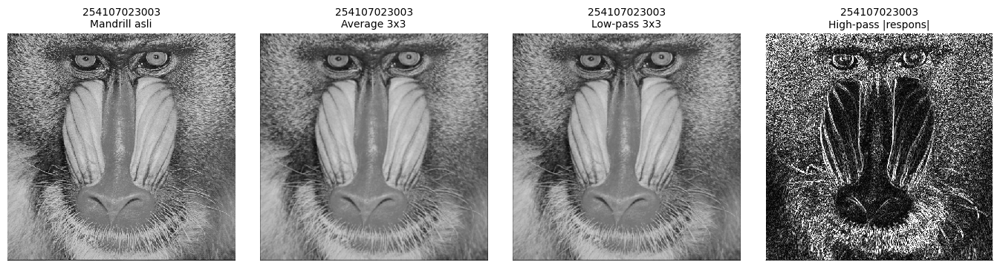

In [12]:
average=np.ones((3,3),dtype=np.float64)/9
low_pass=np.array([[1,1,1],[1,4,1],[1,1,1]],dtype=np.float64)/12
high_pass=np.array([[-1,0,1],[-1,0,3],[-3,0,1]],dtype=np.float64)

hasil_average=konvolusi2d(mandrill_gray,average,padding=1)
hasil_low=konvolusi2d(mandrill_gray,low_pass,padding=1)
hasil_high=konvolusi2d(mandrill_gray,high_pass,padding=1)
assert hasil_average.shape==hasil_low.shape==hasil_high.shape==mandrill_gray.shape
tampil([mandrill_gray,uint8(hasil_average),uint8(hasil_low),uint8(np.abs(hasil_high))],
       ['Mandrill asli','Average 3x3','Low-pass 3x3','High-pass |respons|'],kolom=4,ukuran=3.4)

**Analisis:** Average dan low-pass mengurangi detail halus. High-pass memperjelas tepi dan tekstur. Respons tepi ditampilkan sebagai nilai absolut.

### 3. Sharpen dan emboss

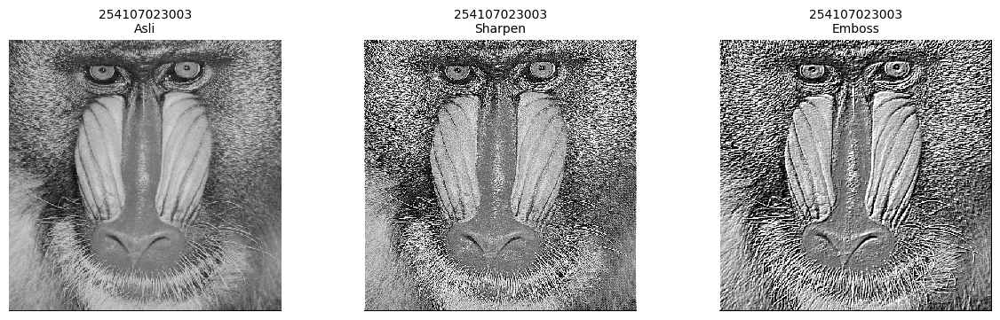

In [13]:
sharpen=np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],dtype=np.float64)
emboss=np.array([[-2,-1,0],[-1,1,1],[0,1,2]],dtype=np.float64)
hasil_sharp=konvolusi2d(mandrill_gray,sharpen,padding=1)
hasil_emboss=konvolusi2d(mandrill_gray,emboss,padding=1)
tampil([mandrill_gray,uint8(hasil_sharp),uint8(hasil_emboss)],
       ['Asli','Sharpen','Emboss'])

**Analisis:** Sharpen mempertegas detail, sedangkan emboss memberi kesan relief dari perbedaan terang-gelap.

### 4. Left Sobel dan deteksi tepi 8 tetangga
Kernel 8 tetangga pada modul diberi label “Canny”, tetapi sebenarnya Laplacian. Canny yang lengkap dicoba pada bagian E.

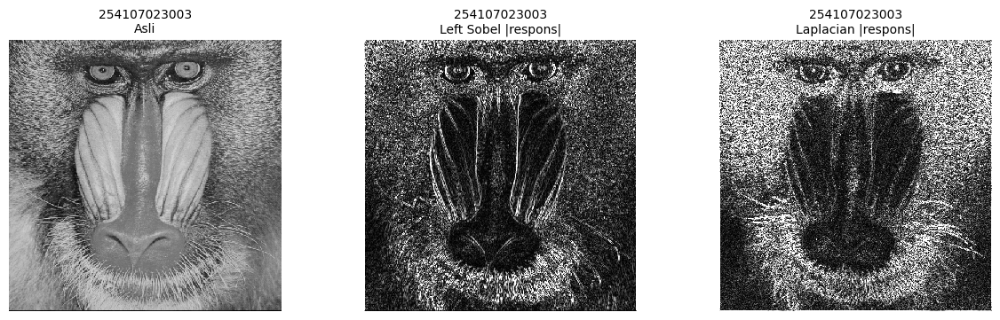

In [14]:
left_sobel=np.array([[1,0,-1],[2,0,-2],[1,0,-1]],dtype=np.float64)
laplacian=np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]],dtype=np.float64)
hasil_sobel=konvolusi2d(mandrill_gray,left_sobel,padding=1)
hasil_lap=konvolusi2d(mandrill_gray,laplacian,padding=1)
tampil([mandrill_gray,uint8(np.abs(hasil_sobel)),uint8(np.abs(hasil_lap))],
       ['Asli','Left Sobel |respons|','Laplacian |respons|'])

### 5. Gaussian blur 21 × 21
Gunakan sigma √21. Padding 10 menjaga ukuran gambar tetap sama.

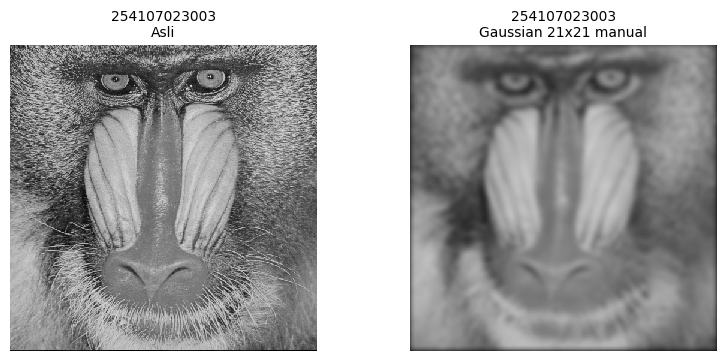

Ukuran asli dan hasil: (512, 512) (512, 512)


In [15]:
kernel_size=21
sigma=math.sqrt(kernel_size)
g=cv.getGaussianKernel(kernel_size,sigma)
gaussian_kernel=g@g.T
assert np.isclose(gaussian_kernel.sum(),1)
hasil_gauss=konvolusi2d(mandrill_gray,gaussian_kernel,padding=kernel_size//2)
assert hasil_gauss.shape==mandrill_gray.shape
tampil([mandrill_gray,uint8(hasil_gauss)],['Asli','Gaussian 21x21 manual'],kolom=2)
print('Ukuran asli dan hasil:',mandrill_gray.shape,hasil_gauss.shape)

**Analisis:** Kernel besar membuat gambar lebih halus, tetapi detail kecil ikut hilang. Seluruh penyaringan pada bagian D memakai fungsi manual.

## E. FILTER LIBRARY DAN FILTER MODERN
### Percobaan 1 - Gaussian, sharpen, dan Canny

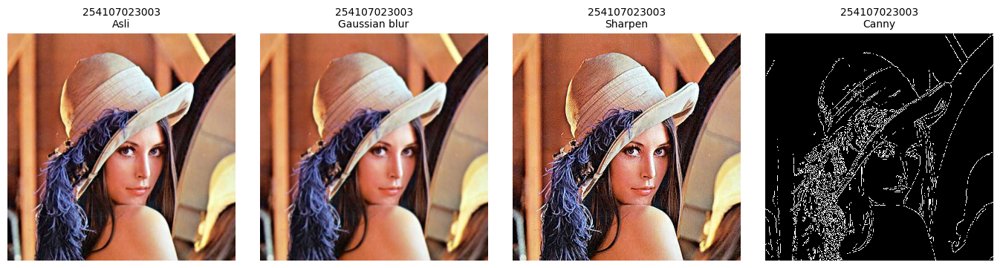

In [16]:
blur=cv.GaussianBlur(lena,(7,7),1)
tajam=cv.filter2D(lena,-1,sharpen)
edges=cv.Canny(lena_gray,100,200)
tampil([lena,blur,tajam,edges],
       ['Asli','Gaussian blur','Sharpen','Canny'],kolom=4,ukuran=3.4)

**Analisis:** Gaussian menghaluskan, sharpen mempertegas detail, dan Canny menampilkan garis tepi.

### Percobaan 2 - Bilateral dan edge-preserving
`edgePreservingFilter` dipakai sebagai alternatif pada contoh modul; fungsi ini bukan Guided Filter.

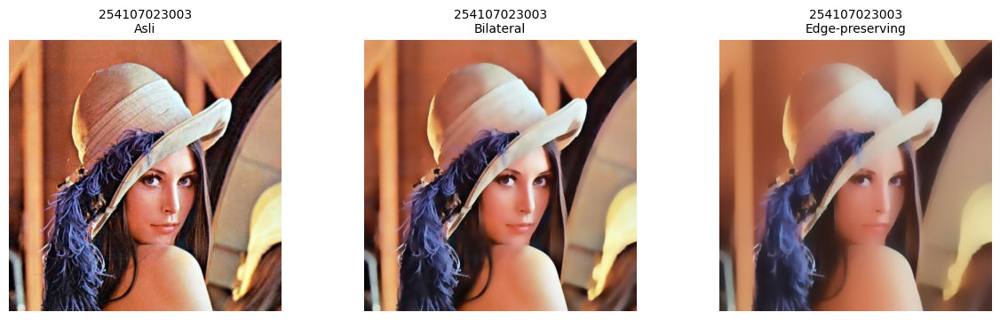

In [17]:
bilateral=cv.bilateralFilter(lena,d=15,sigmaColor=100,sigmaSpace=100)
edge_preserve=cv.edgePreservingFilter(lena,flags=1,sigma_s=100,sigma_r=0.9)
tampil([lena,bilateral,edge_preserve],['Asli','Bilateral','Edge-preserving'])

**Analisis:** Kedua filter menghaluskan area warna sambil mempertahankan batas objek. Pada edge-preserving, tekstur menjadi lebih rata.

### Percobaan 3 - Feature map CNN
Bandingkan dua inisialisasi bobot dengan seed berbeda. Model belum dilatih.

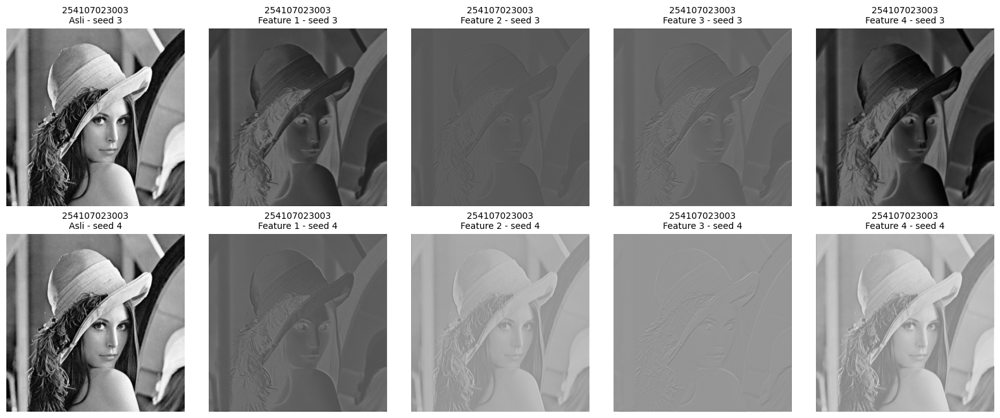

Bentuk keluaran CNN: (1, 4, 512, 512)
Selisih maksimum kedua inisialisasi: 2.431809425354004


In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Conv2d(1,4,kernel_size=3,stride=1,padding=1)

    def forward(self,x):
        return self.conv(x)

masukan=torch.from_numpy(lena_gray.astype(np.float32)/255)[None,None,:,:]
feature_sets=[]
for seed in [SEED,SEED+1]:
    torch.manual_seed(seed)
    model=SimpleCNN().eval()
    with torch.no_grad():
        fitur=model(masukan)
        ulang=model(masukan)
    assert fitur.shape==(1,4,*lena_gray.shape)
    assert torch.equal(fitur,ulang)
    feature_sets.append(fitur[0].numpy())

vmin=min(float(a.min()) for a in feature_sets)
vmax=max(float(a.max()) for a in feature_sets)
fig,axes=plt.subplots(2,5,figsize=(16,6.5),layout='constrained')
for baris,(seed,fitur) in enumerate(zip([SEED,SEED+1],feature_sets)):
    axes[baris,0].imshow(lena_gray,cmap='gray',vmin=0,vmax=255)
    axes[baris,0].set_title(f'{NIM}\nAsli - seed {seed}')
    for i in range(4):
        axes[baris,i+1].imshow(fitur[i],cmap='gray',vmin=vmin,vmax=vmax)
        axes[baris,i+1].set_title(f'{NIM}\nFeature {i+1} - seed {seed}')
for ax in axes.flat:
    ax.axis('off')
plt.show()
print('Bentuk keluaran CNN:',(1,)+feature_sets[0].shape)
print('Selisih maksimum kedua inisialisasi:',float(np.abs(feature_sets[0]-feature_sets[1]).max()))

**Analisis:** Bobot acak yang berbeda menghasilkan feature map berbeda. Jika model dan input tetap, hasilnya tetap sama. Feature map ini belum menunjukkan fitur yang dipelajari dari pelatihan.

### Percobaan 4 - Beauty dan vintage

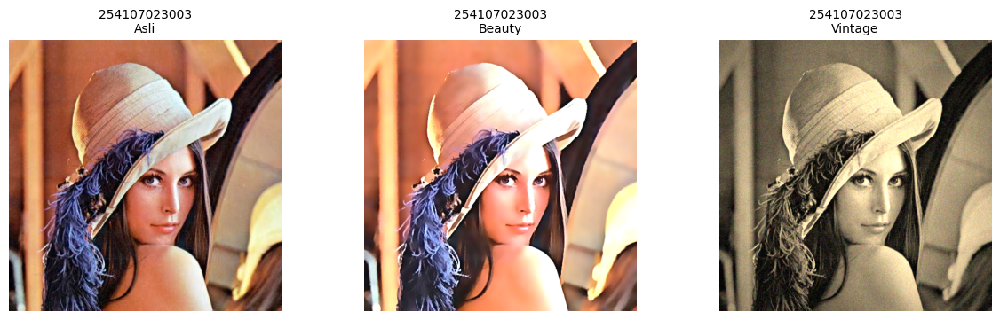

In [19]:
smooth=cv.bilateralFilter(lena,15,75,75)
soft=cv.GaussianBlur(smooth,(0,0),3)
detail=cv.addWeighted(smooth,1.5,soft,-0.5,0)
beauty=uint8(detail.astype(np.float32)*1.2+15)

# Matriks sepia untuk urutan kanal BGR.
sepia_matrix=np.array([[0.131,0.534,0.272],
                       [0.168,0.686,0.349],
                       [0.189,0.769,0.393]],dtype=np.float32)
sepia=cv.transform(lena.astype(np.float32),sepia_matrix)
h,w=lena.shape[:2]
gx=cv.getGaussianKernel(w,w*0.6)
gy=cv.getGaussianKernel(h,h*0.6)
mask=gy@gx.T
mask/=mask.max()
grain=np.random.default_rng(SEED).normal(0,12,sepia.shape)
vintage=uint8(sepia*mask[:,:,None]+grain)
tampil([lena,beauty,vintage],['Asli','Beauty','Vintage'])

**Analisis:** Beauty menghaluskan tekstur dan mencerahkan gambar. Vintage memberi warna sepia, sudut gelap, dan grain.

### Percobaan 5 - Anime/cartoon

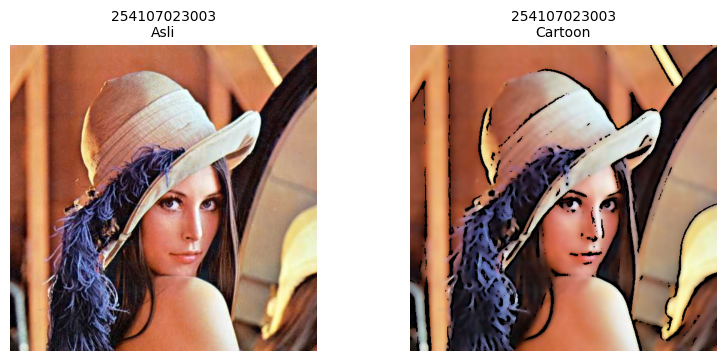

In [20]:
gray_halusan=cv.medianBlur(lena_gray,7)
garis=cv.adaptiveThreshold(gray_halusan,255,cv.ADAPTIVE_THRESH_MEAN_C,
                          cv.THRESH_BINARY,9,9)
warna=cv.bilateralFilter(lena,9,200,200)
cartoon=cv.bitwise_and(warna,warna,mask=garis)
tampil([lena,cartoon],['Asli','Cartoon'],kolom=2)

**Analisis:** Warna dibuat lebih rata dan garis tepi dipertahankan agar gambar terlihat seperti kartun.

### Percobaan 6 - Malam dan glow

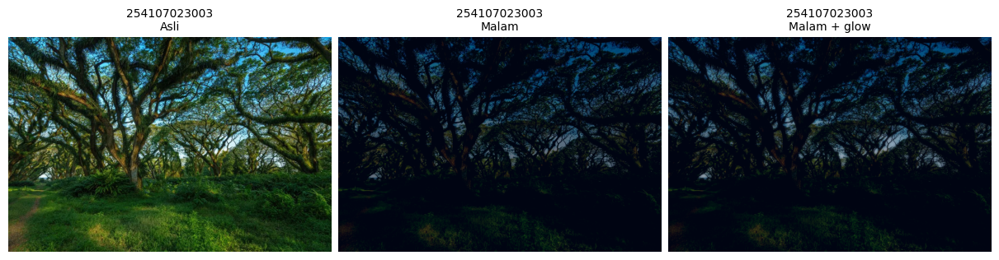

In [21]:
gelap=np.clip(djawatan.astype(np.float32)*0.6-40,0,255)
malam=uint8(gelap+np.array([18,4,0],dtype=np.float32))

# Glow hanya berasal dari bagian yang terang pada citra asli.
gray_hutan=cv.cvtColor(djawatan,cv.COLOR_BGR2GRAY).astype(np.float32)
terang=np.clip((gray_hutan-150)/105,0,1)
sumber_glow=djawatan.astype(np.float32)*terang[:,:,None]
kernel_glow=np.ones((15,15),np.float32)/225
glow=cv.filter2D(sumber_glow,-1,kernel_glow)
night_glow=uint8(malam.astype(np.float32)+0.3*glow)
tampil([djawatan,malam,night_glow],['Asli','Malam','Malam + glow'])

**Analisis:** Kecerahan diturunkan dan warna biru ditambah untuk memberi kesan malam. Glow memberi cahaya lembut pada area terang.

### Percobaan 7 - Pagi dan kabut

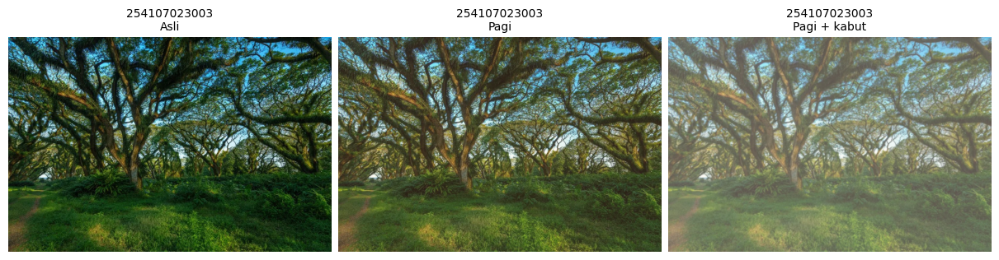

In [22]:
soft=djawatan.astype(np.float32)*0.9+20
pagi=uint8(soft+np.array([0,8,20],dtype=np.float32))
g=cv.getGaussianKernel(3,3)
lembut=cv.filter2D(pagi,-1,g@g.T)
kabut=uint8(lembut.astype(np.float32)*0.75+255*0.25)
tampil([djawatan,pagi,kabut],['Asli','Pagi','Pagi + kabut'])

**Analisis:** Warna hangat memberi kesan pagi. Lapisan putih mengurangi kontras dan membuat efek kabut.

## TUGAS PRAKTIKUM
### 1. Mean dan Median pada noise Salt and Pepper
Tambahkan 2% salt dan 2% pepper pada posisi berbeda, lalu bandingkan Mean 3 × 3 dan Median 3 × 3. Jumlah posisi dibulatkan ke piksel terdekat; seed dibuat tetap agar hasil dapat diulang.

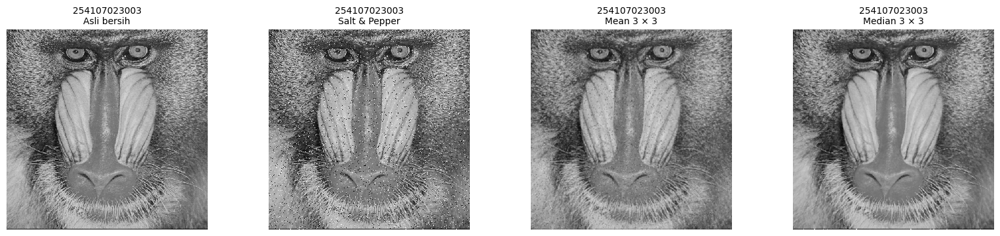

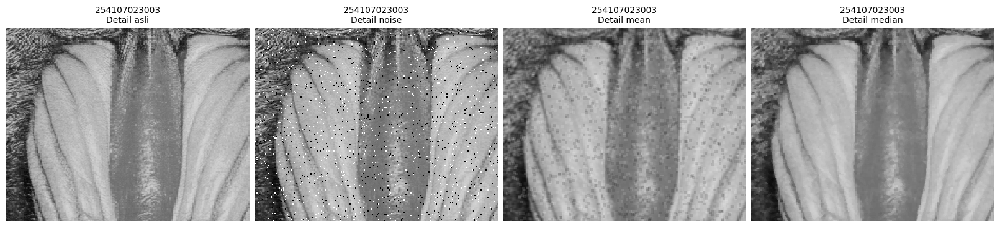

Salt: 5243 posisi (2.00005%)
Pepper: 5243 posisi (2.00005%)
Noise           : PSNR 19.55 dB terhadap citra bersih
Mean 3 × 3      : PSNR 22.14 dB terhadap citra bersih
Median 3 × 3    : PSNR 23.54 dB terhadap citra bersih


In [23]:
def psnr_tugas(acuan, hasil):
    mse = np.mean((acuan.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else float(10 * np.log10(255.0 ** 2 / mse))


def crop_tugas(img):
    # Area sekitar mata, hidung, dan bulu untuk melihat detail serta noise.
    h, w = img.shape[:2]
    return img[int(0.18*h):int(0.58*h), int(0.20*w):int(0.70*w)]


rng_noise = np.random.default_rng(SEED)
n_noise = int(round(0.02 * mandrill_gray.size))
posisi_noise = rng_noise.choice(mandrill_gray.size, size=2*n_noise, replace=False)
posisi_salt, posisi_pepper = np.split(posisi_noise, 2)
assert len(np.unique(posisi_noise)) == 2*n_noise

noisy_tugas = mandrill_gray.copy()
noisy_tugas.flat[posisi_salt] = 255
noisy_tugas.flat[posisi_pepper] = 0
mean_tugas = cv.blur(noisy_tugas, (3, 3))
median_tugas = cv.medianBlur(noisy_tugas, 3)

tampil([mandrill_gray, noisy_tugas, mean_tugas, median_tugas],
       ['Asli bersih', 'Salt & Pepper', 'Mean 3 × 3', 'Median 3 × 3'], kolom=4)
tampil([crop_tugas(img) for img in [mandrill_gray, noisy_tugas, mean_tugas, median_tugas]],
       ['Detail asli', 'Detail noise', 'Detail mean', 'Detail median'], kolom=4)

psnr_noise = {nama: psnr_tugas(mandrill_gray, img) for nama, img in [
    ('Noise', noisy_tugas), ('Mean 3 × 3', mean_tugas), ('Median 3 × 3', median_tugas)]}
print(f'Salt: {n_noise} posisi ({100*n_noise/mandrill_gray.size:.5f}%)')
print(f'Pepper: {n_noise} posisi ({100*n_noise/mandrill_gray.size:.5f}%)')
for nama, nilai in psnr_noise.items():
    print(f'{nama:<16}: PSNR {nilai:.2f} dB terhadap citra bersih')

**Analisis:** Median lebih bersih karena nilai ekstrem tidak ikut menentukan nilai tengah, sedangkan mean menyebarkan bintik menjadi bercak buram. Pada foto ini, PSNR median **23,54 dB**, lebih tinggi daripada mean **22,14 dB** dan gambar bernoise **19,55 dB**. Sebagian tekstur halus tetap berkurang setelah penyaringan.

### 2. Sharpening 3 × 3 dan 5 × 5
Kaburkan citra dengan Gaussian 5 × 5, sigma 1,0. Kedua kernel dibuat dengan resep yang sama, **2 × identitas − rata-rata**, dan jumlah koefisien 1 agar perbandingan tidak sekadar mengubah kecerahan.

Kernel 3 × 3, jumlah = 1.000000
[[-0.1111 -0.1111 -0.1111]
 [-0.1111  1.8889 -0.1111]
 [-0.1111 -0.1111 -0.1111]]
Kernel 5 × 5, jumlah = 1.000000
[[-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04  1.96 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]]


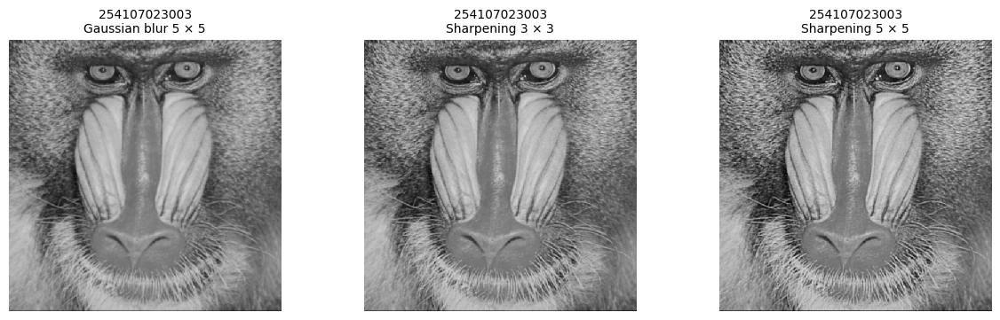

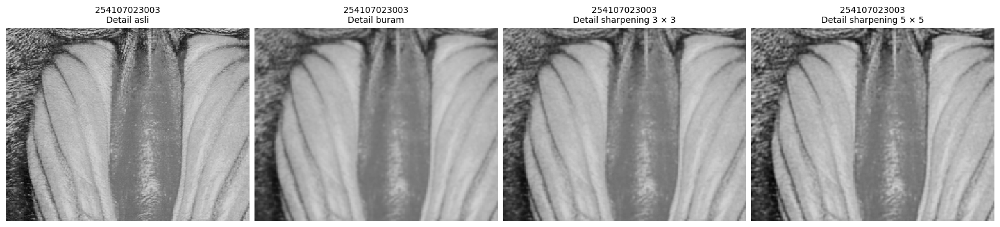

Buram           : PSNR 23.70 dB terhadap citra asli
Sharpen 3 × 3   : PSNR 25.10 dB terhadap citra asli
Sharpen 5 × 5   : PSNR 25.65 dB terhadap citra asli
Sharpen 3 × 3: 0.000% respons di luar 0–255 sebelum clipping
Sharpen 5 × 5: 0.000% respons di luar 0–255 sebelum clipping


In [24]:
buram_tugas = cv.GaussianBlur(mandrill_gray, (5, 5), 1.0)
kernel_tugas = {}
tajam_tugas = {}
clip_tugas = {}
for ukuran_kernel in (3, 5):
    kernel = -np.ones((ukuran_kernel, ukuran_kernel), dtype=np.float64) / ukuran_kernel**2
    kernel[ukuran_kernel//2, ukuran_kernel//2] += 2
    assert np.isclose(kernel.sum(), 1.0)
    kernel_tugas[ukuran_kernel] = kernel
    respons = cv.filter2D(buram_tugas, cv.CV_64F, kernel, borderType=cv.BORDER_REFLECT_101)
    tajam_tugas[ukuran_kernel] = np.rint(np.clip(respons, 0, 255)).astype(np.uint8)
    clip_tugas[ukuran_kernel] = float(100*np.mean((respons < 0) | (respons > 255)))
    print(f'Kernel {ukuran_kernel} × {ukuran_kernel}, jumlah = {kernel.sum():.6f}')
    print(np.round(kernel, 4))

tampil([buram_tugas, tajam_tugas[3], tajam_tugas[5]],
       ['Gaussian blur 5 × 5', 'Sharpening 3 × 3', 'Sharpening 5 × 5'], kolom=3)
tampil([crop_tugas(img) for img in [mandrill_gray, buram_tugas, tajam_tugas[3], tajam_tugas[5]]],
       ['Detail asli', 'Detail buram', 'Detail sharpening 3 × 3', 'Detail sharpening 5 × 5'], kolom=4)

psnr_sharpen = {nama: psnr_tugas(mandrill_gray, img) for nama, img in [
    ('Buram', buram_tugas), ('Sharpen 3 × 3', tajam_tugas[3]), ('Sharpen 5 × 5', tajam_tugas[5])]}
for nama, nilai in psnr_sharpen.items():
    print(f'{nama:<16}: PSNR {nilai:.2f} dB terhadap citra asli')
for ukuran_kernel, persen in clip_tugas.items():
    print(f'Sharpen {ukuran_kernel} × {ukuran_kernel}: {persen:.3f}% respons di luar 0–255 sebelum clipping')

**Analisis:** Pada foto ini, **5 × 5** dipilih karena alur hidung dan bulu lebih tegas; PSNR-nya **25,65 dB**, dibandingkan **25,10 dB** untuk 3 × 3. Pada crop tidak tampak halo kuat dan kedua hasil tidak memerlukan clipping, tetapi tekstur juga ikut diperkuat. Pilihan ini cocok untuk foto buram ringan yang serupa, bukan berarti 5 × 5 selalu terbaik pada semua foto atau tingkat noise.

### 3. Filter kartun sederhana
Gabungkan penghalusan warna bilateral dengan garis hasil adaptive thresholding. Masker bernilai 0 membuat garis hitam; bagian bernilai 255 mempertahankan warna.

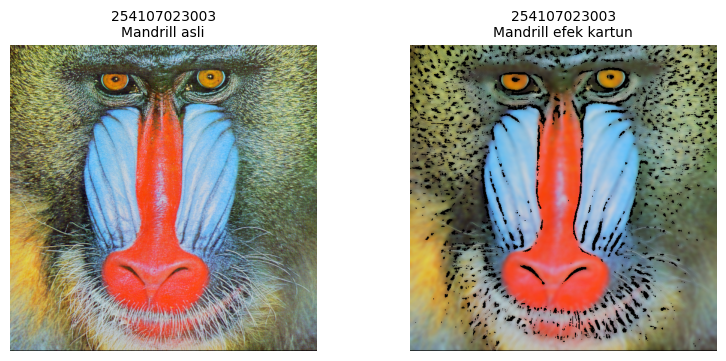

In [25]:
def kartun(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    halus_gray = cv.medianBlur(gray, 7)
    mask = cv.adaptiveThreshold(halus_gray, 255,
                               cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    warna = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)
    return cv.bitwise_and(warna, warna, mask=mask)


kartun_mandrill = kartun(mandrill)
tampil([mandrill, kartun_mandrill], ['Mandrill asli', 'Mandrill efek kartun'], kolom=2)

**Analisis:** Warna pada pipi dan hidung menjadi lebih rata, sedangkan tepi mata dan hidung terlihat sebagai garis hitam. Tekstur bulu yang rapat masih menghasilkan banyak bintik/garis hitam, sehingga hasilnya lebih sederhana daripada gambar asli tetapi belum menyerupai ilustrasi kartun yang bersih.